In [11]:
import tensorflow_datasets as tfds
import tensorflow as tf
import tensorflow as tf
import os, shutil, pathlib
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt



In [ ]:
data_dir = "/home/kass/machine-learning-python-template/models/ML_Deep/dogs-vs-cats/train"

IMG_SIZE = (160, 160)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,   
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


I0000 00:00:1758864594.006891    5043 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [6]:
print("Clases detectadas:", train_ds.class_names)

train_count = tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE
val_count   = tf.data.experimental.cardinality(val_ds).numpy() * BATCH_SIZE

print("Imágenes en Train:", train_count)
print("Imágenes en Val:", val_count)

Clases detectadas: ['cats', 'dogs']
Imágenes en Train: 20000
Imágenes en Val: 5024


In [7]:
AUTOTUNE = tf.data.AUTOTUNE
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,   
    weights="imagenet"
)

base_model.trainable = False  

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),   
    layers.Dropout(0.3),              
    layers.Dense(1, activation="sigmoid")  
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


2025-09-25 23:31:49.705416: I external/local_xla/xla/service/service.cc:163] XLA service 0x780be8004680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-25 23:31:49.705506: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060, Compute Capability 8.9
2025-09-25 23:31:50.035262: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-25 23:31:51.684277: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300
2025-09-25 23:32:01.774390: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv (f32[32,192,10,10]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,192,21,21]{3,2,1,0}, f32[192,1,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, feature_group_count=192, custom_call_target="__cudnn$con

623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9292 - loss: 0.1708

2025-09-25 23:32:45.824559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-09-25 23:32:46.024751: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=0} for conv (f32[8,576,10,10]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,576,10,10]{3,2,1,0}, f32[576,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=576, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-25 23:32:46.304668: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optim

625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 63ms/step - accuracy: 0.9601 - loss: 0.1055 - val_accuracy: 0.9730 - val_loss: 0.0689
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9751 - loss: 0.0669 - val_accuracy: 0.9726 - val_loss: 0.0631
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9766 - loss: 0.0647 - val_accuracy: 0.9746 - val_loss: 0.0644
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9773 - loss: 0.0620 - val_accuracy: 0.9744 - val_loss: 0.0654
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.9796 - loss: 0.0595 - val_accuracy: 0.9764 - val_loss: 0.0634


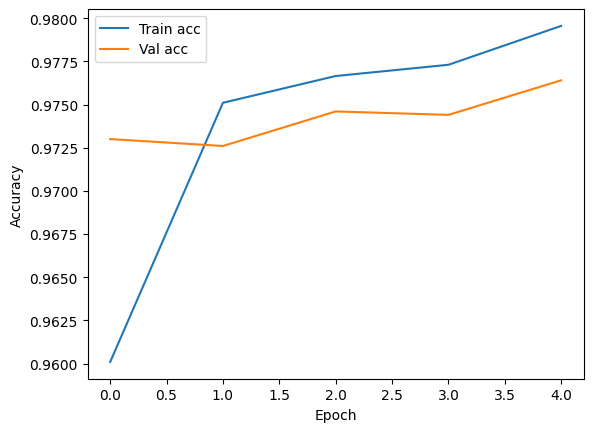

In [12]:
plt.plot(history.history["accuracy"], label="Train acc")
plt.plot(history.history["val_accuracy"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [13]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(train_ds, validation_data=val_ds, epochs=3)

Epoch 1/3


2025-09-25 23:36:26.174094: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-09-25 23:36:26.350732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-09-25 23:36:26.446920: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-09-25 23:36:26.727417: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-09-25 23:36:26.775036: E external/local_xla/xla/service

625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 71ms/step - accuracy: 0.9431 - loss: 0.1421 - val_accuracy: 0.9746 - val_loss: 0.0713
Epoch 2/3


2025-09-25 23:37:43.283540: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16777472 bytes after encountering the first element of size 16777472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9668 - loss: 0.0861

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.9683 - loss: 0.0817 - val_accuracy: 0.9786 - val_loss: 0.0601
Epoch 3/3
  3/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.9931 - loss: 0.0242

2025-09-25 23:38:18.680731: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16777472 bytes after encountering the first element of size 16777472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9731 - loss: 0.0689

2025-09-25 23:38:51.172026: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 16777472 bytes after encountering the first element of size 16777472 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.9759 - loss: 0.0614 - val_accuracy: 0.9808 - val_loss: 0.0553


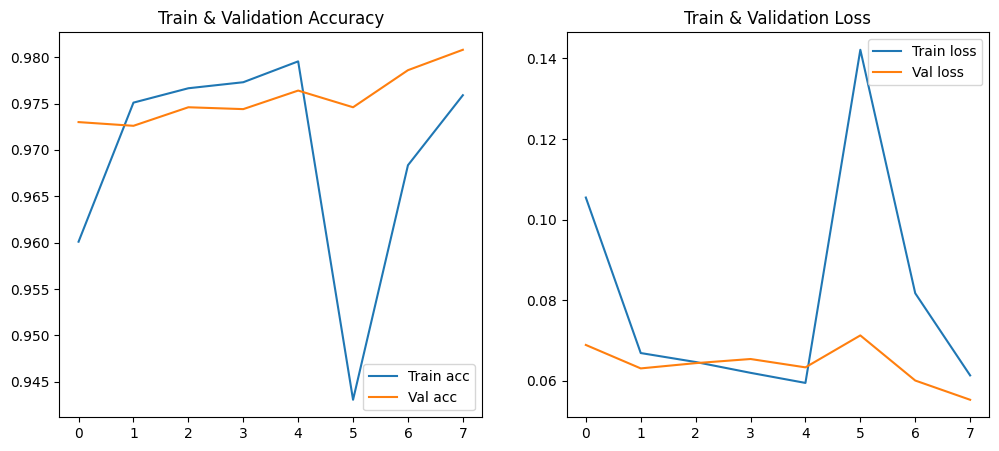

In [14]:
acc = history.history["accuracy"] + history_ft.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_ft.history["val_accuracy"]

loss = history.history["loss"] + history_ft.history["loss"]
val_loss = history.history["val_loss"] + history_ft.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train acc")
plt.plot(epochs_range, val_acc, label="Val acc")
plt.legend(loc="lower right")
plt.title("Train & Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train loss")
plt.plot(epochs_range, val_loss, label="Val loss")
plt.legend(loc="upper right")
plt.title("Train & Validation Loss")

plt.show()

In [15]:
model.save("dogs_vs_cats_final.h5")